In [1]:
!pip install torchsummary
!pip install gdown
!pip install torch torchvision torchaudio
!pip install tensorflow

In [2]:
import os
import shutil
import json
import matplotlib.pyplot as plt
import random
import PIL.Image as Image
import numpy as np
import pandas as pd
import time
import shutil
import math
import pathlib
import sys


from mpl_toolkits.axes_grid1 import ImageGrid

from skimage.restoration import denoise_tv_chambolle
import cv2
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
import torchsummary as summary

import tensorflow as tf

from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

plt.ion()
from IPython.display import clear_output

2025-12-25 08:21:04.643271: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/is/hdd/programming/individualnoeZadanie/Image_processing/Индивид.Задание/.venv/lib64/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Готовим пути для данных

In [3]:
root = '/home/is/hdd/pics/archive/scan_doc_rotation'         
image_paths = os.path.join(root, 'images')
label_paths = os.path.join(root, 'labels')

In [4]:
test_list_path = os.path.join(root, 'test_list.json')   

with open(test_list_path) as f:
    test_list = json.load(f)     # names of test images (test images dont have labels)    

In [5]:
train_list_path = os.path.join(root, 'train_list.json')

with open(train_list_path) as f:
    train_list = json.load(f)   # names of train images 

label_list = [x.split('.')[0] + '.txt' for x in train_list]   # names of label text files.  

## Вывод одного изображения и взятие рандомного изображения

ID of document is : 116
Rotation angle is : -2.141483335550476


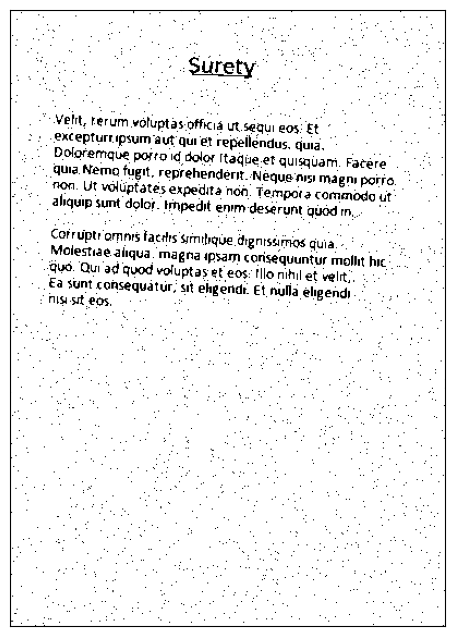

In [6]:
def get_random_img(r=[0, 499]):
    id = random.randint(r[0], r[1])
    sample_image_path = os.path.join(image_paths, train_list[id])
    sample_label_path = os.path.join(label_paths, label_list[id])
    return id, sample_image_path, sample_label_path
    
def display_image(path=None, img=None):
    if path is not None:
        img = Image.open(path)

    plt.figure(figsize=(8, 8))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap='gray');

    
# generates random id and get it's image path and label path
id, sample_image_path, sample_label_path = get_random_img()

# displays image
display_image(path=sample_image_path)

# writes id and angle of sample in output
with open(sample_label_path) as f:
    angle = f.read()
print('ID of document is :', id)
print('Rotation angle is :', angle)

## Вывод сетки изображений

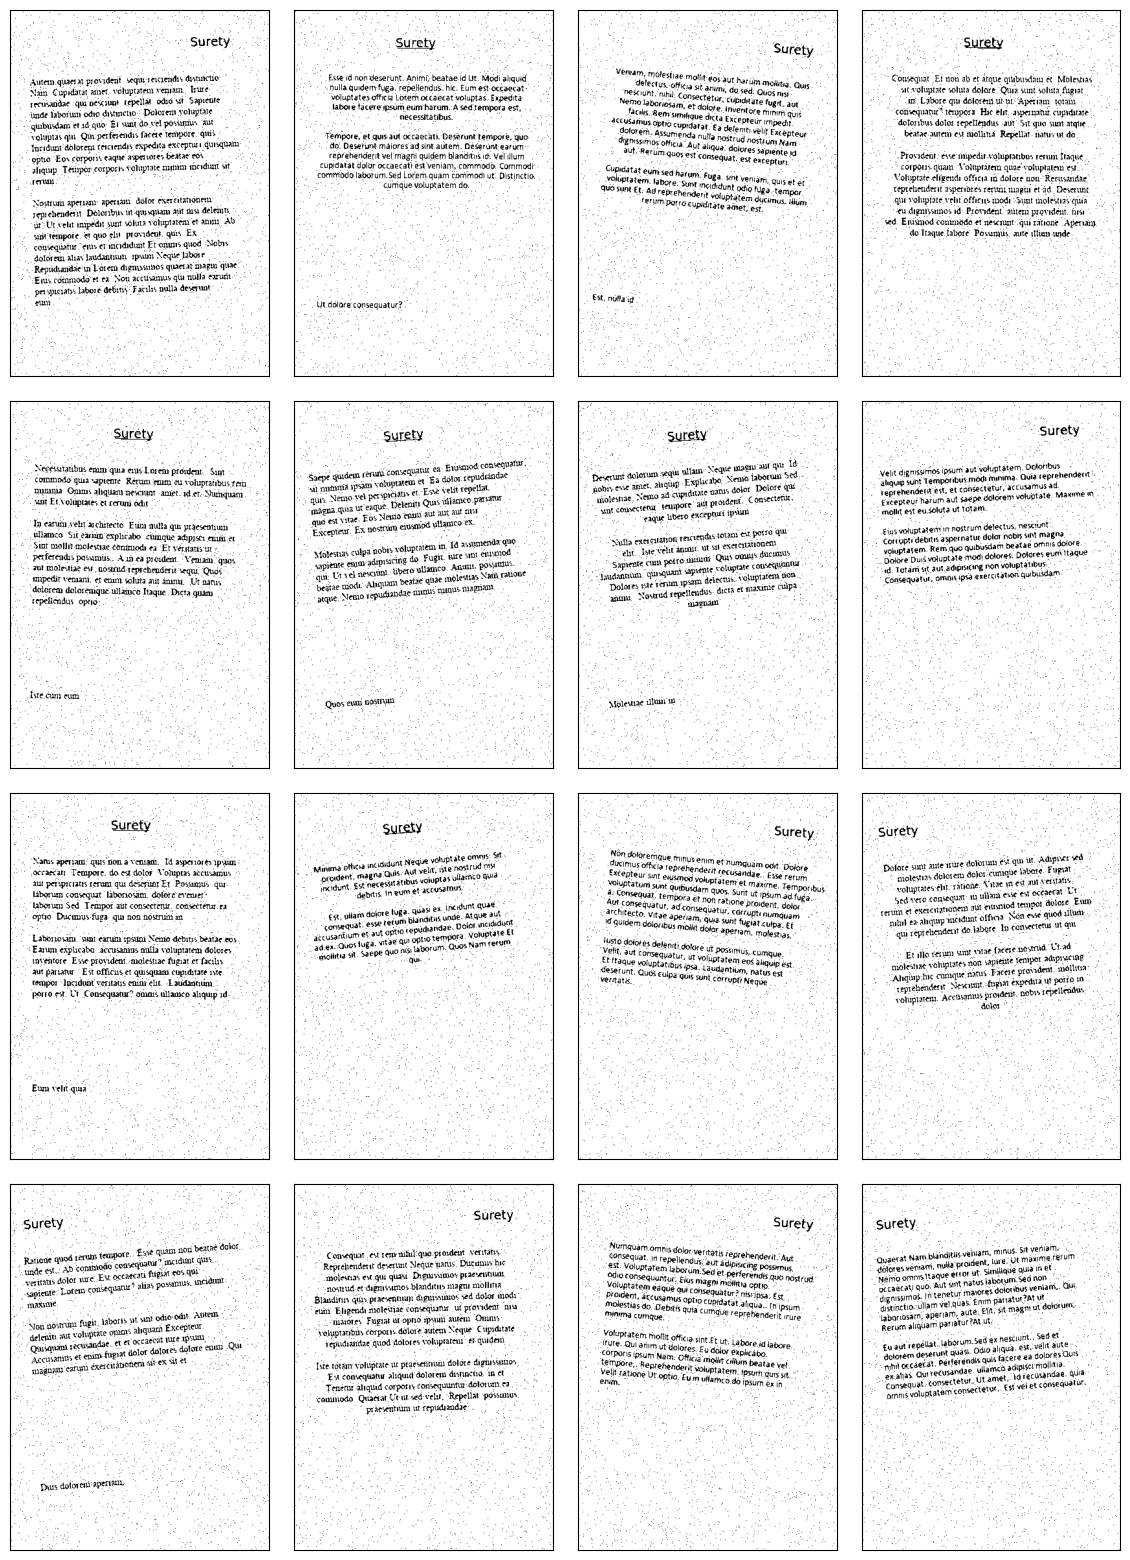

In [7]:
def display_image_grid(images, n=10, angles=None):
    fig = plt.figure(figsize=(20, 20))
    grid = ImageGrid(fig, 111,  
                     nrows_ncols=(n, n),  
                     axes_pad=0.25, 
                     )

    i = 0
    for ax, im in zip(grid, images):
        ax.imshow(im, cmap='gray');
        ax.set_xticks([])
        ax.set_yticks([])
        if angles is not None:
            angle = angles[i] - 5
            ax.set_title(label=str(angle))
        i += 1

    plt.show()

sampled_images = []
sampled_ids = []

for i in range(16):
    id, sample_image_path, sample_label_path = get_random_img()
    if id not in sampled_ids:
        img = Image.open(sample_image_path)
        sampled_ids.append(id)
        sampled_images.append(img)

display_image_grid(sampled_images, 4)

## Импортируем функции

In [8]:
!git clone https://github.com/d4nst/RotNet.git

fatal: destination path 'RotNet' already exists and is not an empty directory.


In [9]:
# import module we'll need to import our custom module
from shutil import copyfile

# copy our file into the working directory (make sure it has .py suffix)
#copyfile(src = "./RotNet/utils.py", dst = "../Индивид.Задание/my_functions.py")
#Поменял то что нужно так как там устаревшая версия
# import all our functions
from my_functions import *

## Делаем нормальные данные 

In [10]:
# Getting image names and labels and saving them in "labels" dictionary 
labels = {}
for textfile in label_list:
    path = os.path.join(label_paths, textfile)
    with open(path) as f:
        label = float(f.read())
    file_name = textfile.split('.')[0]
    labels[file_name] = label

In [11]:
# Creating new images by rotating them 
new_images = []
new_labels = []
for image_id, angle in labels.items():
    image_path = os.path.join(image_paths, image_id+'.png')
    img = Image.open(image_path)                                # open image as PIL Image
    img = np.array(img)                                         # convert PIL Image to np array
    corrected_img = rotate(img, -angle)                         # rotate image to get corrected image
    
    sample_angles = random.sample(range(-45, 45), 50)           # sample 50 numbers between -45 to 45
    for sample_angle in sample_angles:
        new_img = generate_rotated_image(corrected_img,         # generate a valid rotated image based on sample_angle and
                                         sample_angle,          #     it resize image to 64*64
                                         size=(128, 128),
                                         crop_center=True,
                                         crop_largest_rect=True)
        new_images.append(new_img)
        new_labels.append(sample_angle)

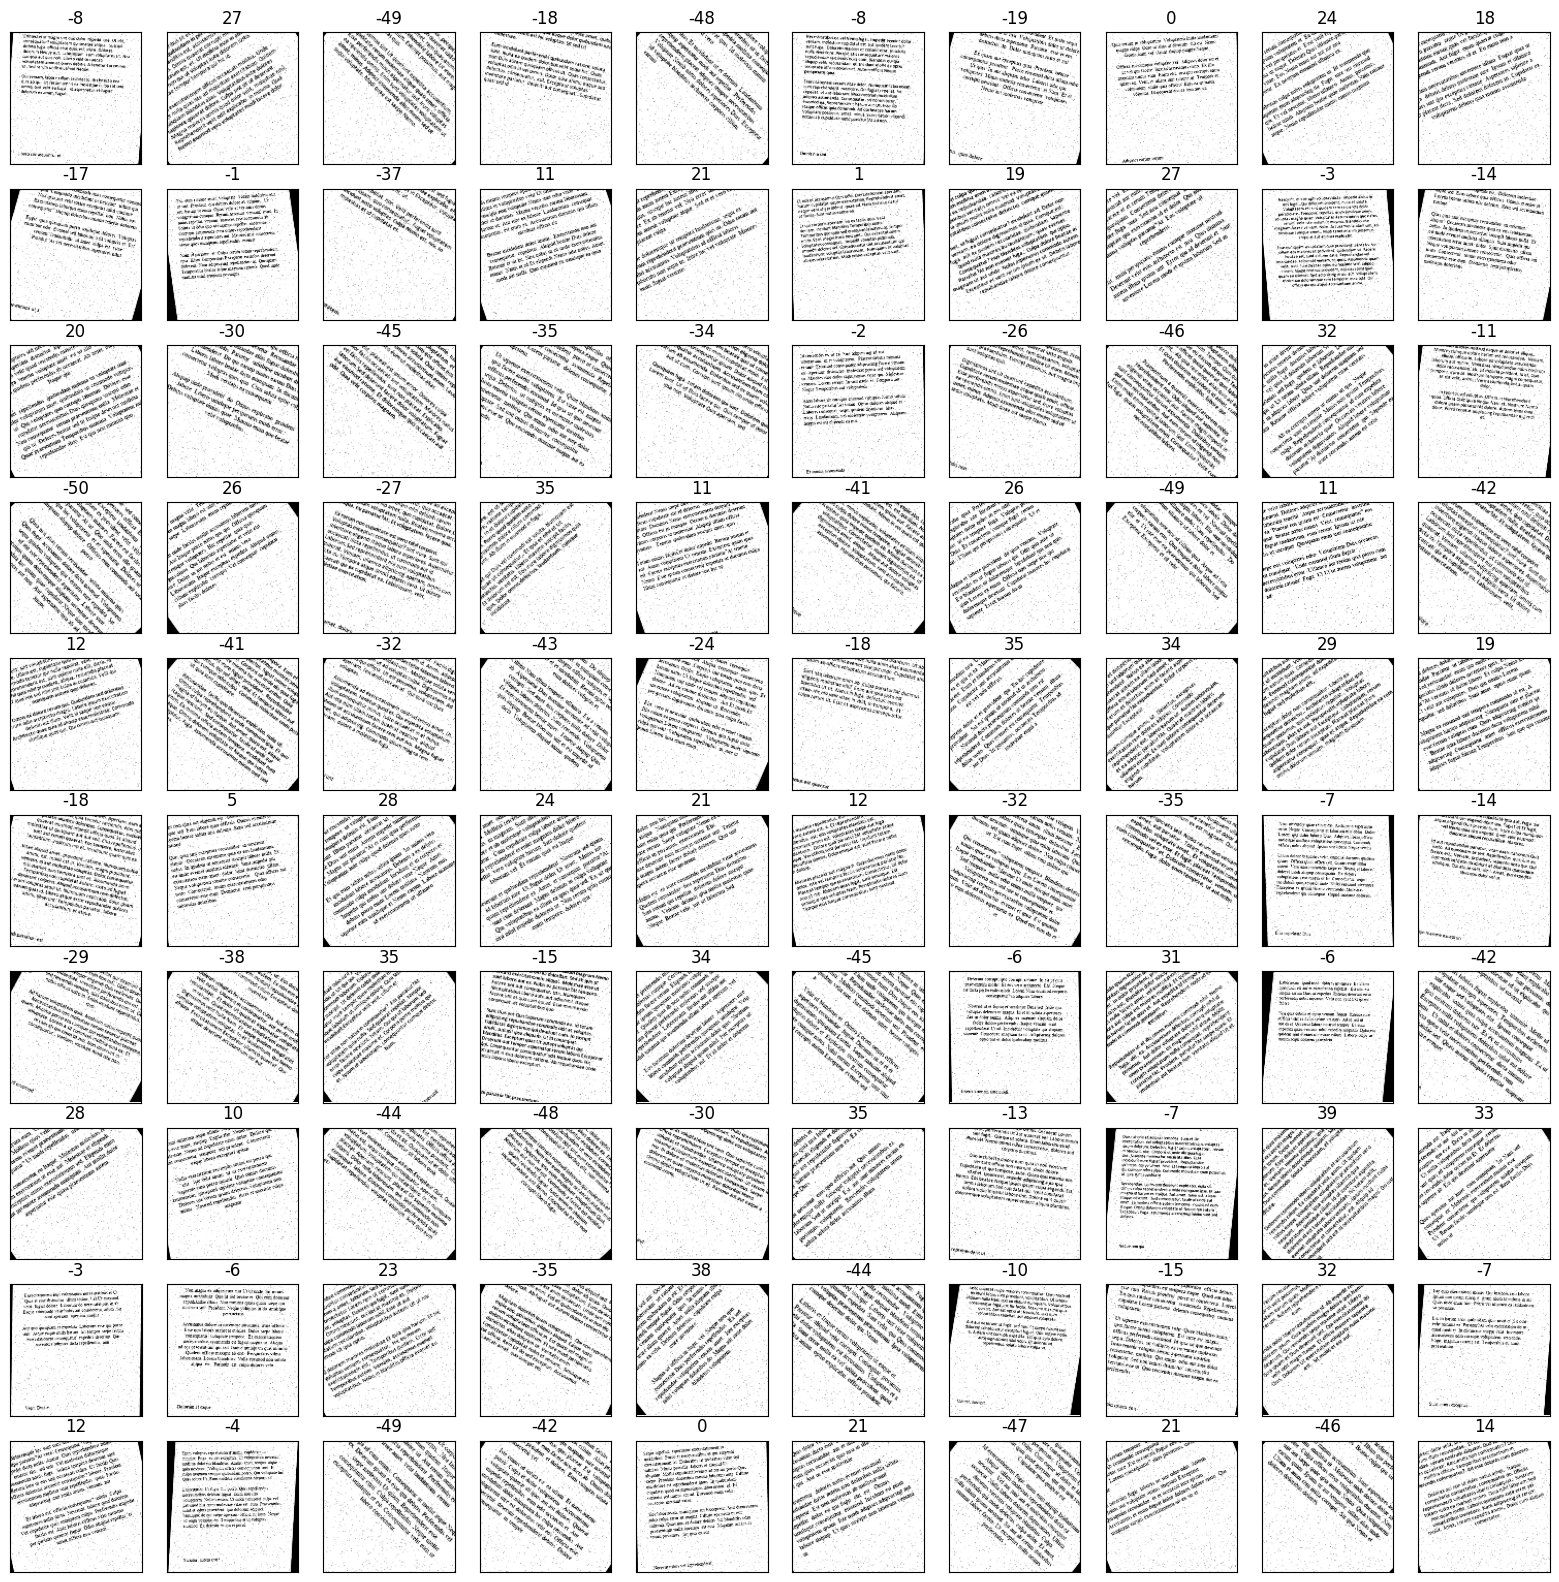

In [12]:
# N is number of all images in dataset
N = len(new_images)

# Sampling 100 images to display
sampled_image_indecies = random.sample(range(N), 100)
sampled_images = [Image.fromarray(new_images[i]) for i in sampled_image_indecies]
sampled_labels = [new_labels[i] for i in sampled_image_indecies]

# Displays 10*10 grid of rotated images from new dataset. The number in above of each image, is rotated angle
display_image_grid(sampled_images, 10, sampled_labels)

## Предобработка

In [13]:
nb_classes = len(np.unique(new_labels))

data = np.stack(new_images, axis=0)
X = data.copy()
Y = to_categorical(np.array(new_labels) + 45, nb_classes)

# Приведи X к float32 (требуется для модели)
X = X.astype('float32') / 255.0
X = (X > 0.5).astype('float32')  # бинаризация + сразу float32

# Убедись, что Y — float32 (не обязательно, но экономит память)
Y = Y.astype('float32')

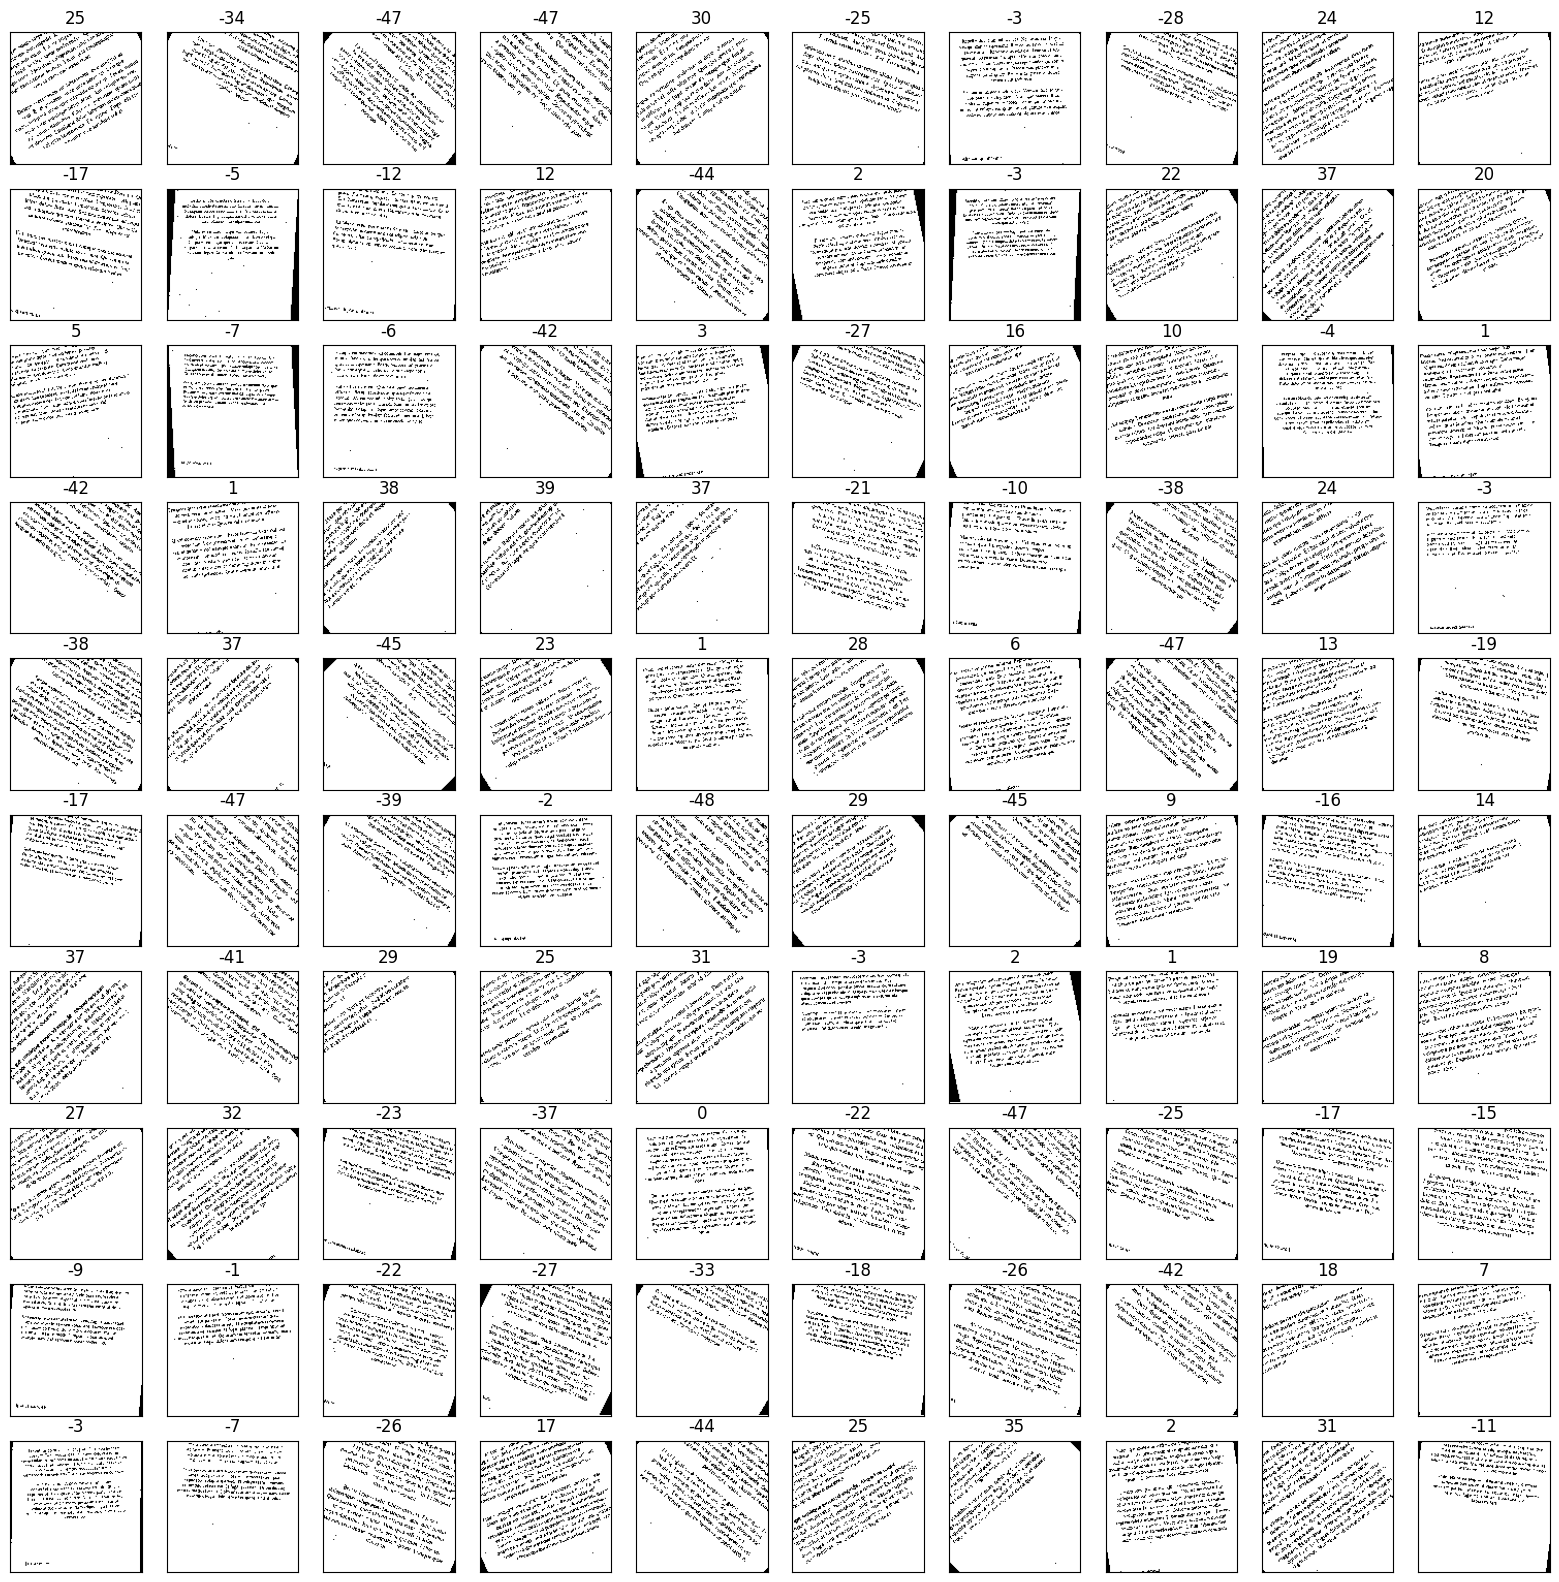

In [14]:
# Sample
sampled_image_indecies = random.sample(range(N), 100)
sampled_images = [Image.fromarray((X[i]*255).astype(np.uint8)) for i in sampled_image_indecies]
sampled_labels = [new_labels[i] for i in sampled_image_indecies]

display_image_grid(sampled_images, 10, sampled_labels)

## Делаем модель

In [15]:
# number of convolutional filters to use
nb_filters = 64
# size of pooling area for max pooling
pool_size = (2, 2)
# convolution kernel size
kernel_size = (3, 3)

In [16]:
nb_train_samples, img_height, img_width = X.shape
img_channels = 1
input_shape = (img_height, img_width, img_channels)

print('Input shape:', input_shape)
print(nb_train_samples, 'train samples')

Input shape: (128, 128, 1)
25000 train samples


### TensorFlow Model

In [17]:
# model definition
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Model



input = Input(shape=(img_height, img_width, img_channels))
x = Conv2D(nb_filters, kernel_size, activation='relu')(input)
x = Conv2D(nb_filters, kernel_size, activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(nb_filters, kernel_size, activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(nb_filters, kernel_size, activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(nb_classes, activation='softmax')(x)

model = Model(inputs=input, outputs=x)

2025-12-25 08:21:48.566989: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,728,794 (6.59 MB)

 Trainable params: 1,728,794 (6.59 MB)

 Non-trainable params: 0 (0.00 B)

### Компиляция модели

In [19]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=[angle_error, 'acc']
)

### Параметры для обучения

In [20]:
batch_size = 32
nb_epoch = 45

### Вызовы

In [21]:
from tensorflow.keras.callbacks import Callback

class PlotLearning(Callback):
    """
    Callback to plot the learning curves of the model during training.
    """
    def on_train_begin(self, logs={}):
        self.metrics = {}
        for metric in logs:
            self.metrics[metric] = []
            

    def on_epoch_end(self, epoch, logs={}):
        # Storing metrics
        for metric in logs:
            if metric in self.metrics:
                self.metrics[metric].append(logs.get(metric))
            else:
                self.metrics[metric] = [logs.get(metric)]
        
        # Plotting
        metrics = [x for x in logs if 'val' not in x]
        
        f, axs = plt.subplots(1, len(metrics), figsize=(15,5))
        clear_output(wait=True)

        for i, metric in enumerate(metrics):
            axs[i].plot(range(1, epoch + 2), 
                        self.metrics[metric], 
                        label=metric)
            if logs['val_' + metric]:
                axs[i].plot(range(1, epoch + 2), 
                            self.metrics['val_' + metric], 
                            label='val_' + metric)
                
            axs[i].legend()
            axs[i].grid()

        plt.tight_layout()
        plt.show()

In [22]:
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard = TensorBoard(log_dir=log_dir)
plotlearning = PlotLearning()
early_stopping = EarlyStopping(patience=5)

### Model Fitting

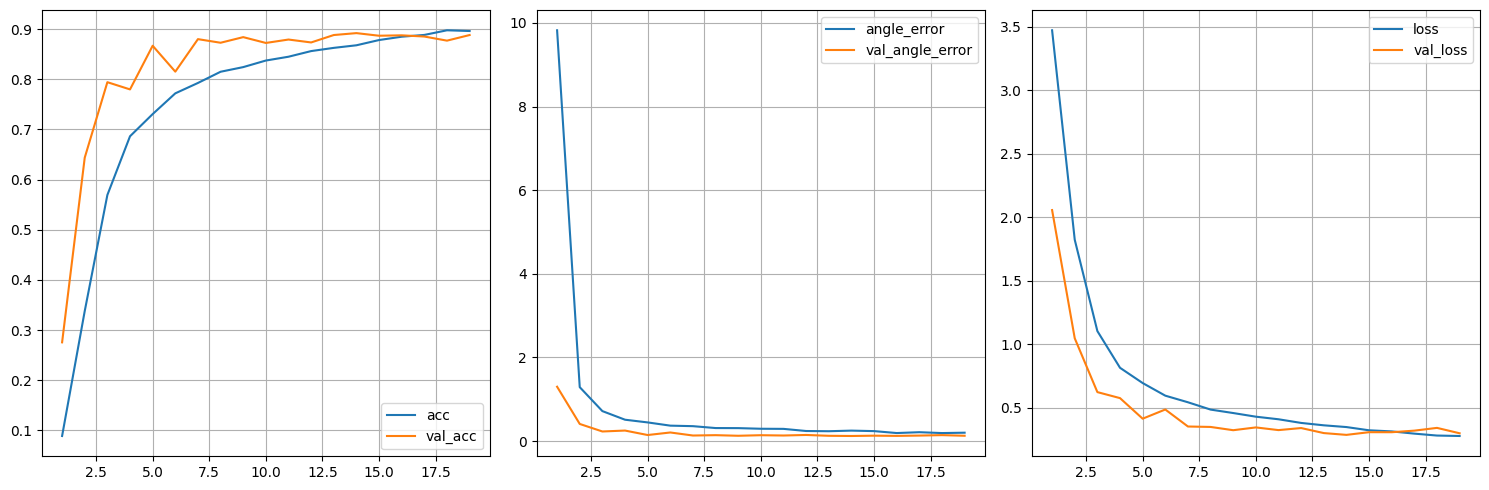

625/625 ━━━━━━━━━━━━━━━━━━━━ 949s 2s/step - acc: 0.8960 - angle_error: 0.1989 - loss: 0.2774 - val_acc: 0.8880 - val_angle_error: 0.1254 - val_loss: 0.2988


In [23]:
model.fit(
    x=X,
    y=Y,
    batch_size=batch_size,
    epochs=nb_epoch,
    validation_split=0.2,
    verbose=1,
    callbacks=[tensorboard, plotlearning, early_stopping]
)

## Оценка

In [24]:
# save image names in a dataframe
test_df = pd.DataFrame(data={'image':list(map(lambda x:x.split('.')[0], test_list)), 'label':np.zeros(len(test_list), int)})

In [25]:
# get images and convert them to array and add to test_images list
test_images = []
for image_name in test_df['image'].values:
    image_path = os.path.join(image_paths, image_name+'.png')
    img = Image.open(image_path)
    img = np.array(img)
    new_img = generate_rotated_image(img,
                                     0,
                                     size=(128, 128),
                                     crop_center=False,
                                     crop_largest_rect=False)
    test_images.append(new_img)

In [26]:
# preparing test data for model
X_test = np.stack(test_images)
X_test = X_test / 255
X_test = np.where(X_test > 0.5, 1, 0)

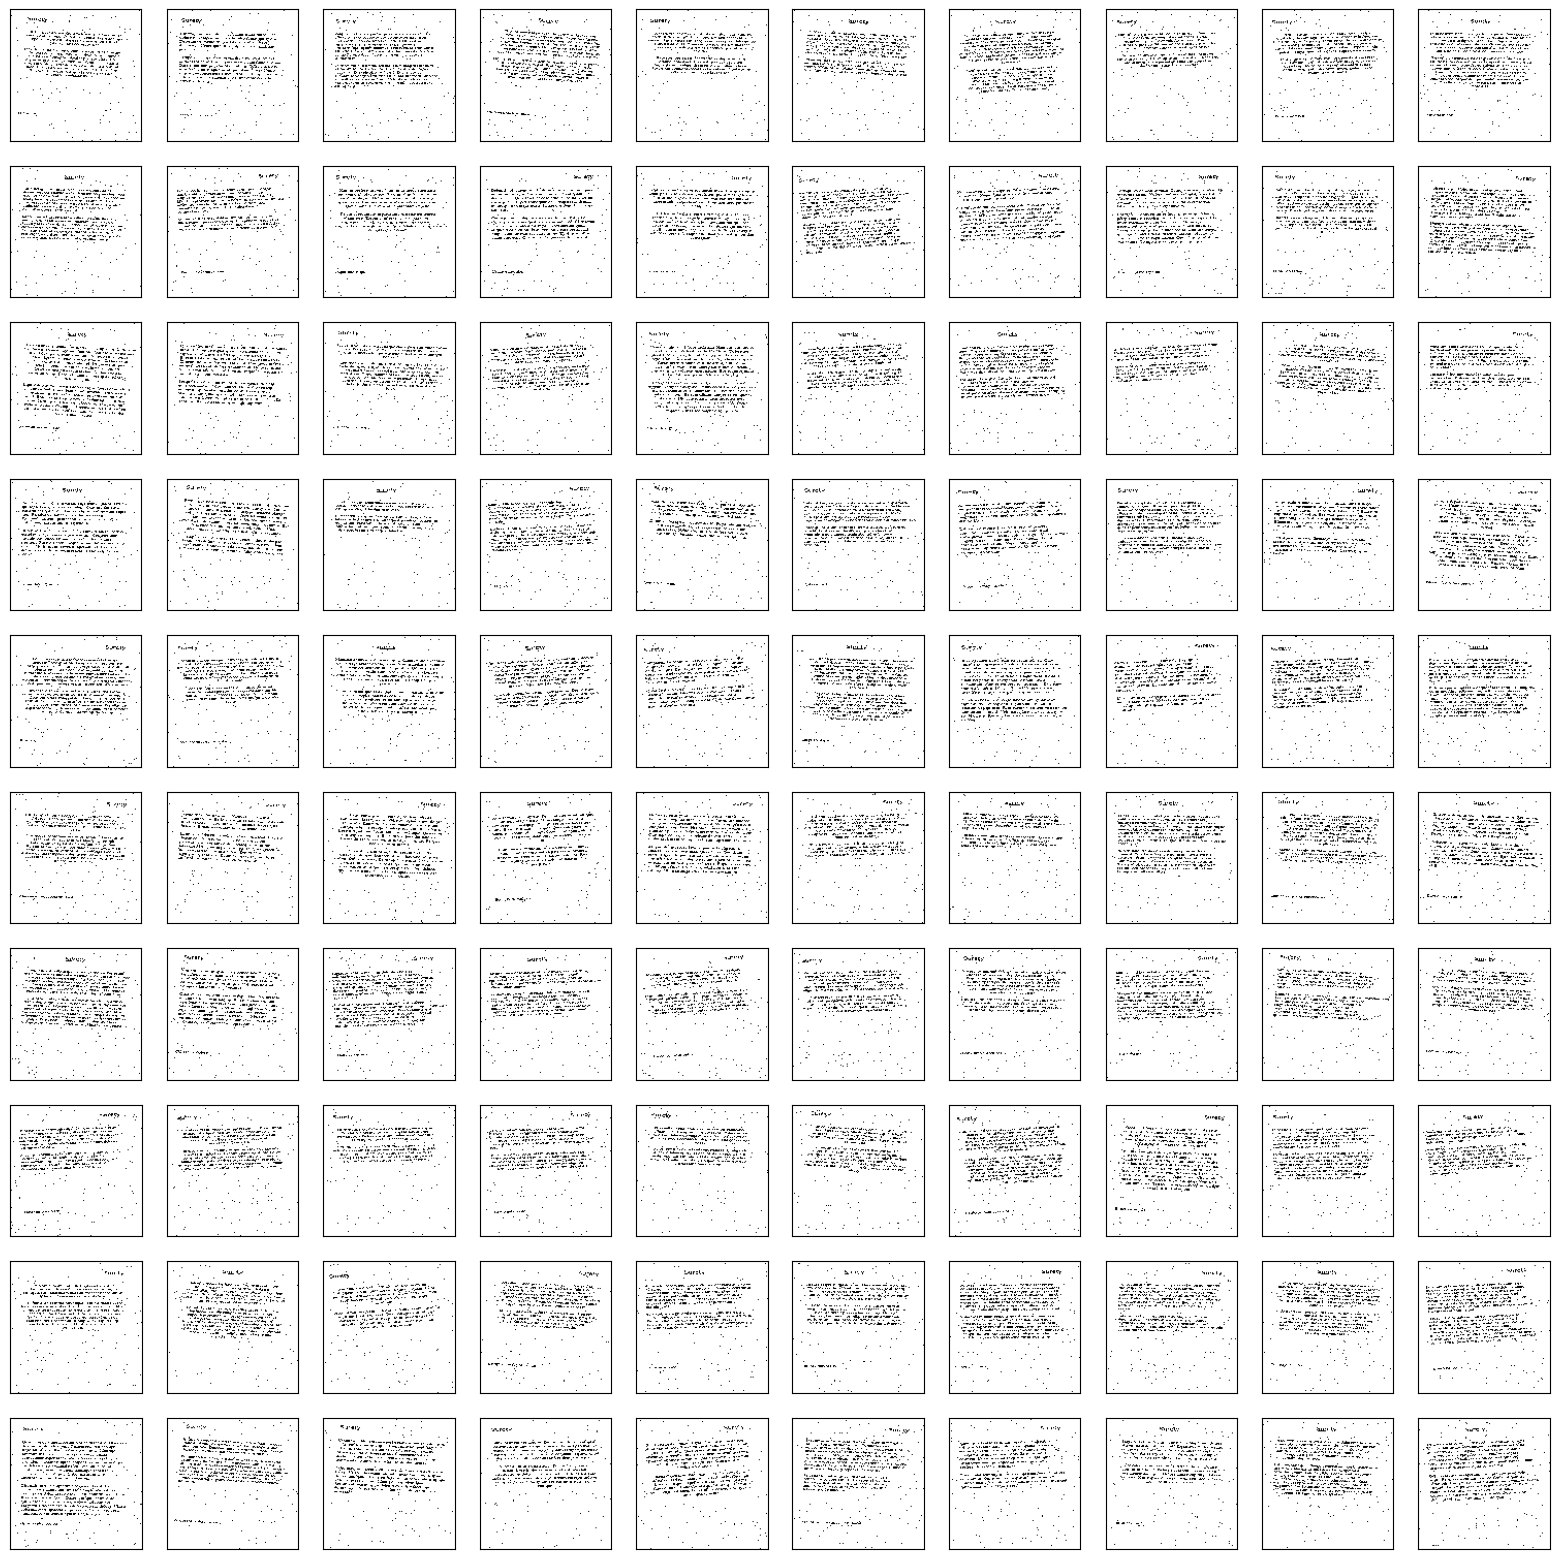

In [27]:
# display test images
display_image_grid(X_test, 10)

In [28]:
# prediction with model
predicted_angles = np.argmax(model(X_test), axis=1) - 45

2025-12-25 13:15:36.240303: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 406425600 exceeds 10% of free system memory.
2025-12-25 13:15:36.345693: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 406425600 exceeds 10% of free system memory.
2025-12-25 13:15:36.451955: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 406425600 exceeds 10% of free system memory.


In [29]:
# correct image rotations
corrected_test_images = []

for i, image_name in enumerate(test_df['image'].values):
    image_path = os.path.join(image_paths, image_name+'.png')
    img = Image.open(image_path)
    img = np.array(img)
    angle = predicted_angles[i]
    corrected_img = rotate(img, -angle)
    corrected_test_images.append(corrected_img)

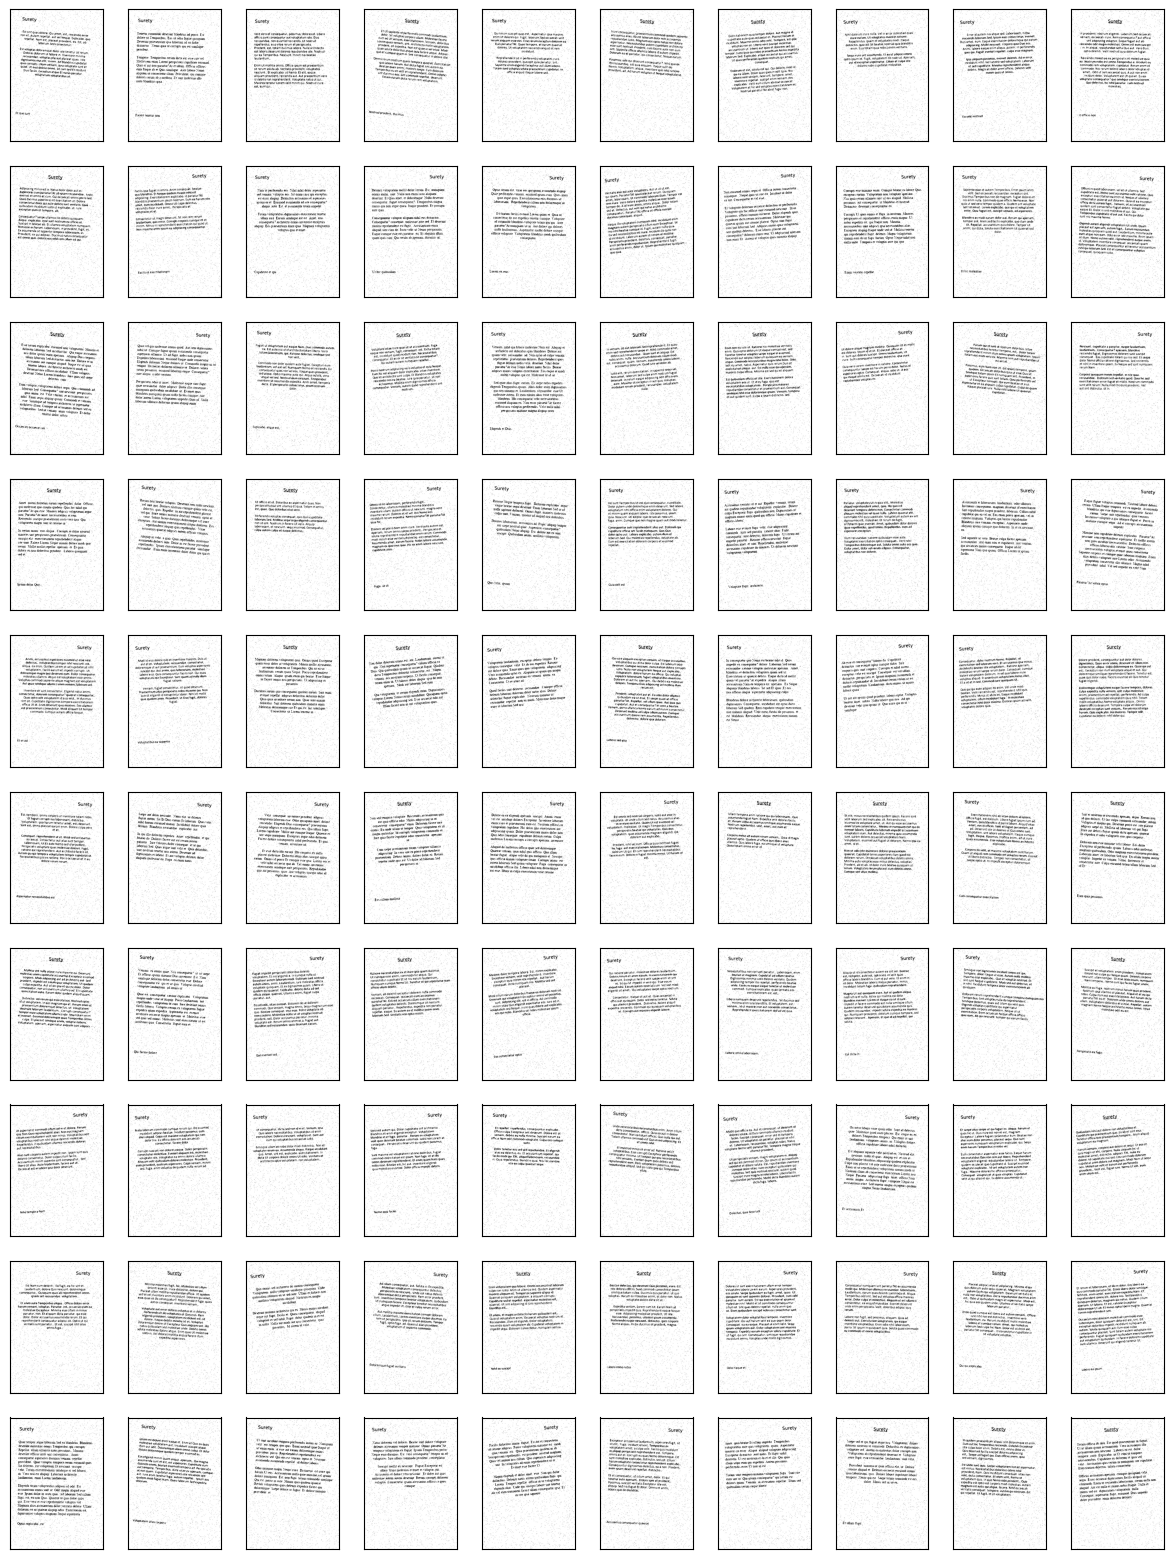

In [30]:
# display corrected test images
display_image_grid(corrected_test_images, 10)